# Mnist dataset classification using Ann

In [35]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.layers import Dense, Flatten
from keras import Sequential
from keras.callbacks import EarlyStopping

In [25]:
import ssl
import certifi

ssl._create_default_https_context = lambda: ssl.create_default_context(
    cafile=certifi.where()
)

In [26]:
from keras.datasets import mnist

(x_train, y_train), (x_test, y_test) = mnist.load_data()

In [27]:
x_train.shape, x_test.shape

((60000, 28, 28), (10000, 28, 28))

In [28]:
y_train.shape, y_test.shape

((60000,), (10000,))

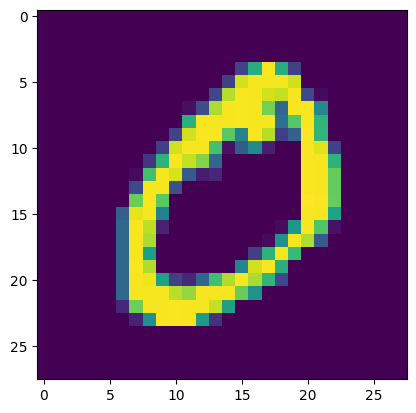

In [30]:
import matplotlib.pyplot as plt
plt.imshow(x_train[1])

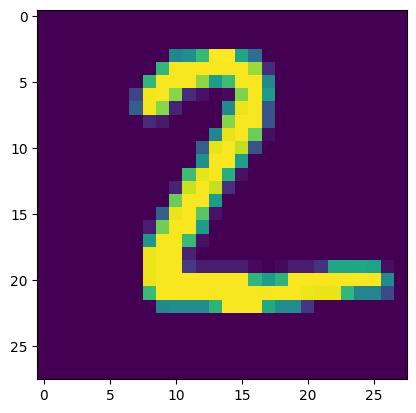

In [31]:
plt.imshow(x_test[1])

In [32]:
x_train = x_train/255
x_test = x_test/255

In [36]:
model = Sequential()

model.add(Flatten(input_shape = (28,28)))
model.add(Dense(128, activation="relu"))
model.add(Dense(10, activation="softmax"))

In [38]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 flatten (Flatten)           (None, 784)               0         
                                                                 
 dense (Dense)               (None, 128)               100480    
                                                                 
 dense_1 (Dense)             (None, 10)                1290      
                                                                 
Total params: 101,770
Trainable params: 101,770
Non-trainable params: 0
_________________________________________________________________


In [46]:
model.compile(loss="sparse_categorical_crossentropy", optimizer='Adam')

In [47]:
history = model.fit(x_train,y_train, epochs=10, validation_split=0.2)

Epoch 1/10
1500/1500 [==============================] - 4s 2ms/step - loss: 0.0153 - val_loss: 0.0971
Epoch 2/10
1500/1500 [==============================] - 4s 3ms/step - loss: 0.0092 - val_loss: 0.1034
Epoch 3/10
1500/1500 [==============================] - 4s 3ms/step - loss: 0.0118 - val_loss: 0.1114
Epoch 4/10
1500/1500 [==============================] - 4s 3ms/step - loss: 0.0071 - val_loss: 0.1070
Epoch 5/10
1500/1500 [==============================] - 4s 3ms/step - loss: 0.0093 - val_loss: 0.1053
Epoch 6/10
1500/1500 [==============================] - 5s 3ms/step - loss: 0.0066 - val_loss: 0.1104
Epoch 7/10
1500/1500 [==============================] - 5s 3ms/step - loss: 0.0082 - val_loss: 0.1029
Epoch 8/10
1500/1500 [==============================] - 3s 2ms/step - loss: 0.0060 - val_loss: 0.1336
Epoch 9/10
1500/1500 [==============================] - 4s 3ms/step - loss: 0.0039 - val_loss: 0.1262
Epoch 10/10
1500/1500 [==============================] - 4s 2ms/step - loss: 0.005

In [57]:
y_prob = model.predict(x_test)

313/313 [==============================] - 0s 1ms/step


In [58]:
y_prob

array([[2.3244299e-16, 1.1634042e-18, 3.9263705e-12, ..., 1.0000000e+00,
        1.3932435e-15, 1.4410987e-08],
       [1.7528592e-16, 3.8952916e-10, 1.0000000e+00, ..., 4.9604331e-24,
        8.1163637e-10, 1.8244030e-24],
       [5.6617205e-10, 9.9999499e-01, 3.2269363e-06, ..., 5.1889288e-07,
        1.1424972e-06, 2.5327242e-11],
       ...,
       [5.2293156e-25, 1.8838219e-19, 1.6327499e-21, ..., 1.7818106e-13,
        2.4215941e-15, 1.1013722e-09],
       [4.2261497e-16, 3.3797747e-20, 2.2358653e-19, ..., 2.9156019e-22,
        1.6458397e-08, 4.2868836e-20],
       [2.6451815e-16, 1.0120455e-24, 6.6167335e-13, ..., 8.4814183e-24,
        4.1012580e-21, 5.7809275e-19]], dtype=float32)

In [59]:
y_pred = y_prob.argmax(axis = 1)

In [60]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_pred)

0.9802

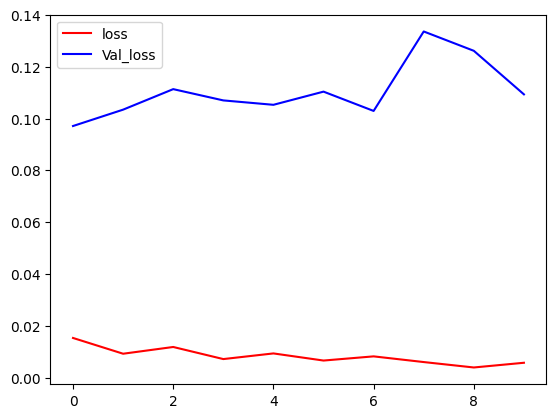

In [68]:
plt.plot(history.history["loss"], color= "red", label = "loss")
plt.plot(history.history["val_loss"], color= "blue", label = "Val_loss")
plt.legend()


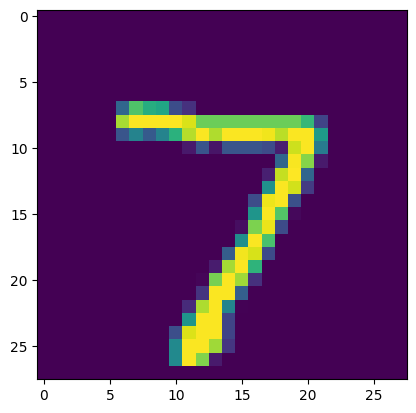

In [74]:
plt.imshow(x_test[0])

In [73]:
model.predict(x_test[0].reshape(1,28,28)).argmax(axis = 1)

1/1 [==============================] - 0s 21ms/step


array([7], dtype=int64)